# D1-02 Brightway architecture and data model

This notebook makes the core Brightway concepts visible before we import a real database later in Day 1.

We work with a tiny toy system so that projects, databases, activities, exchanges, and methods are easy to inspect in code.


## Learning goals

- Understand how `brightway` organizes work into projects.
- See how databases, activities, exchanges, and methods relate to each other.
- Create and inspect a tiny toy database.
- Practice basic `bw2data` inspection patterns before importing BAFU in `D1-04`.


## Background reference

- Mutel, C. (2017). *Brightway: An open source framework for life cycle assessment*. Journal of Open Source Software, 2(12), 236. https://doi.org/10.21105/joss.00236


## 1) Projects are the top-level container

A project contains databases, LCIA methods, and related metadata.
Objects from one project do not interact with objects in another project.


![title](assets/bw_structure.png)

In [1]:
import bw2data as bd

# let's name our project
project_name = 'demo'
# .set_current() will either switch to a project if existing, or create a new one if not.
bd.projects.set_current(project_name)

print('Current project:', bd.projects.current)
print('Number of known projects on this machine:', len(list(bd.projects)))


/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Current project: demo
Number of known projects on this machine: 35


In [ ]:
# you can always delete that project and start anew
# bd.projects.delete_project("demo", delete_dir=True)

## 2) What is inside a project?

A project can contain many databases and many LCIA methods.
Before creating our toy system, inspect the project itself.


In [2]:
print('Project directory:', bd.projects.dir)
print('Databases currently available:', list(bd.databases))
print('Number of methods currently available:', len(bd.methods))


Project directory: /Users/romain/Library/Application Support/Brightway3/demo.fe01ce2a
Databases currently available: ['biosphere', 'technosphere']
Number of methods currently available: 1


## 3) Build a small LCA system

We create:

- one biosphere database
- one technosphere database with two activities
- one LCIA method

The example is deliberately small so that the architecture stays visible.


In [3]:
biosphere_name = 'biosphere'
tech_name = 'technosphere'
method_key = ('climate change', 'GWP')

In [4]:
bd.Database(biosphere_name).write({
    (biosphere_name, 'co2'): {
        'name': 'Carbon dioxide, fossil',
        'unit': 'kilogram',
        'type': 'emission',
    },
    (biosphere_name, 'ch4'): {
        'name': 'Methane, fossil',
        'unit': 'kilogram',
        'type': 'emission',
    }
})

100%|██████████████████████████████████████████| 2/2 [00:00<00:00, 10866.07it/s]

16:02:04+0200 [info     ] Vacuuming database            


Let's check the prensence of `biopshere` in our `demo` project:

In [5]:
"biosphere" in bd.databases

True

Indeed:

In [6]:
bd.databases

Databases dictionary with 2 object(s):
	biosphere
	technosphere

We can select that database:

In [7]:
bio = bd.Database("biosphere")

And check its type and length:

In [8]:
type(bio)

bw2data.backends.base.SQLiteBackend

In [9]:
len(bio)

2

We can check the methods attached to this object by pressing the Tab key:

In [ ]:
bio.

We can, for exmaple, draw a random item from it:

In [12]:
bio.random()

'Methane, fossil' (kilogram, None, None)

In [13]:
item = bio.random()

If everything is an object in Python, what is the type of that object contained in `biosphere`?

In [14]:
type(item)

bw2data.backends.proxies.Activity

This is unexpected. `Carbon dioxide, fossil`, which we otherwise call an **elementary flow**, is an **Activity** here.  
As we will see, this makes sense once to start to look at LCA systems as graph systems.

But for now, let's proceed with building a technosphere database.

In [15]:
# we keep it simple: two activities, "Coal power plant" and "Coal mining", in a database called "technosphere"

# the bd.Database() class can be used either to select or create a database object.
bd.Database(tech_name).write({ # the .write() method of the bd.Database() class expects a dictionary
    (tech_name, 'cpp'): {
        'name': 'Coal power plant',
        'reference product': 'Electricity',
        'unit': 'kilowatt hour',
        'location': 'GLO',
        'exchanges': [ # each activity will typically contain exchanges
            {'input': (tech_name, 'cpp'), 'amount': 1.0, 'type': 'production'}, # this is a `production` exchange (going out)
            {'input': (tech_name, 'coal'), 'amount': 0.4, 'type': 'technosphere'}, # this is a `technosphere` exchange (coming in form another process)
            {'input': (biosphere_name, 'co2'), 'amount': 2.6 * 0.4, 'type': 'biosphere'}, # this is a `biosphere` exchange, our CO2 emission.
        ],
    },
    (tech_name, 'coal'): {
        'name': 'Coal mining',
        'reference product': 'Coal',
        'unit': 'kilogram',
        'location': 'GLO',
        'exchanges': [
            {'input': (tech_name, 'coal'), 'amount': 1.0, 'type': 'production'},
            {'input': (tech_name, 'cpp'), 'amount': 0.025, 'type': 'technosphere'},
            {'input': (biosphere_name, 'co2'), 'amount': 0.3, 'type': 'biosphere'},
            {'input': (biosphere_name, 'ch4'), 'amount': 0.05, 'type': 'biosphere'},
        ],
    },
})

100%|██████████████████████████████████████████| 2/2 [00:00<00:00, 19373.23it/s]

16:02:24+0200 [info     ] Vacuuming database            


There are already some important concepts in the cell above:
* activities usually have an outgoing exchange (**production** exchange)
* activities may have **technosphere** exchanges going in (input from other man-made processes)
* activities may have **biosphere** exchanges going in (interaction between the activity and the environment)

This raises a question, though...

* What is a **CO2 emission an input**? Because `Carbon dioxide, fossil` in an Activity, just like `Coal power plant`.

But let's explore our new `technosphere` database, to see it clearly.

## 4) A database contains activities

Activities are the objects we query when we build product systems.


In [16]:
db = bd.Database(tech_name)
print('Database object:', db)
print('Number of activities:', len(db))

for act in db:
    print('-', act['name'], '| key =', act.key, '| location =', act.get('location'))


Database object: Brightway2 SQLiteBackend: technosphere
Number of activities: 2
- Coal power plant | key = ('technosphere', 'cpp') | location = GLO
- Coal mining | key = ('technosphere', 'coal') | location = GLO


In [17]:
# since the database is small, we can load it into memory directly, as a dictionary
# let's pretty-print that
from pprint import pprint
pprint(db.load())

{('technosphere', 'coal'): {'code': 'coal',
                            'database': 'technosphere',
                            'exchanges': [{'amount': 1.0,
                                           'input': ('technosphere', 'coal'),
                                           'output': ('technosphere', 'coal'),
                                           'type': 'production'},
                                          {'amount': 0.025,
                                           'input': ('technosphere', 'cpp'),
                                           'output': ('technosphere', 'coal'),
                                           'type': 'technosphere'},
                                          {'amount': 0.3,
                                           'input': ('biosphere', 'co2'),
                                           'output': ('technosphere', 'coal'),
                                           'type': 'biosphere'},
                                          {'amount': 0.05,


For each exchange, you can interpret `input` as **supplier"" and `output` as **consumer**. Obviously, the **consumer"" is always the same activities across the exchanges. The *tuples* for `input` and `output` correspond to a unique identifier (or `key`) of the **supplier** or **conusmer**. It's usually made of the database it belongs to, plus the activity code.

In fact, there's a convenience function that helps us select the activity object if we know its identifier:

In [18]:
act_mine = bd.get_activity(('technosphere', 'coal')) # that's the activity key
act_mine

'Coal mining' (kilogram, GLO, None)

Now, another way `brightway` refers to activities is by using `id` too. Yes, it's a bit confusing: we have two concepts for essentially the same thing, `key` and `id`.

In [19]:
# this works
act = bd.get_activity(("technosphere", "cpp")) # here we use the `key`
act

'Coal power plant' (kilowatt hour, GLO, None)

In [20]:
act.id

301356317363486720

In [23]:
# and this also works
bd.get_activity(act.id) # here we use the `id`

'Coal power plant' (kilowatt hour, GLO, None)

In [24]:
print(f"Here is {act_mine['name']}'s key: {act_mine.key}, and here is its id: {act_mine.id}.")

Here is Coal mining's key: ('technosphere', 'coal'), and here is its id: 301356317363486721.


Let's just say that `key` is often used to refer to an activity as an object, while `id` is more used to refer to an activity as an entry in the `technosphere` matrix -- that's for later.

Up there, we loaded the entire database into memory and printed it. Of course, when the database is several thousand in size, we cannot do that.  
Hence, we can use functions to help us find activities we're interested in.

We can also use a simple **list comprehension**:

In [25]:
act_cpp = [act for act in db if "plant" in act["name"]]
act_cpp

['Coal power plant' (kilowatt hour, GLO, None)]

In [26]:
act_cpp = act_cpp[0]
act_cpp

'Coal power plant' (kilowatt hour, GLO, None)

In [27]:
# act_A is an object, as everything in Python
# and because it is an object, it has methods as attributes
act_cpp.  # press tab

SyntaxError: invalid syntax (3729487746.py, line 3)

## 5) An activity contains exchanges

Exchanges link an activity to:

- itself, through a production exchange
- another activity, through a technosphere exchange
- an elementary flow (which is also an "activity object" here), through a biosphere exchange


In [28]:
act_cpp = bd.get_activity((tech_name, 'cpp'))

print('Selected activity:', act_cpp['name'])
print('Unit:', act_cpp['unit'])
print('Location:', act_cpp.get('location'))

Selected activity: Coal power plant
Unit: kilowatt hour
Location: GLO


In [29]:
print('Production exchanges:')
for exc in act_cpp.production():
    print('  -', exc.input['name'], '| amount =', exc['amount'])

Production exchanges:
  - Coal power plant | amount = 1.0


In [30]:
print('Technosphere exchanges:')
for exc in act_cpp.technosphere():
    print('  -', exc.input['name'], '| amount =', exc['amount'])

print('Biosphere exchanges:')
for exc in act_cpp.biosphere():
    print('  -', exc.input['name'], '| amount =', exc['amount'])


Technosphere exchanges:
  - Coal mining | amount = 0.4
Biosphere exchanges:
  - Carbon dioxide, fossil | amount = 1.04


In [31]:
# we can also iterate over all exchanges
# and put that into a nice pandas' DataFrame
import pandas as pd

pd.DataFrame(
    [
        [
            e["amount"],
            e["type"],
            e.input["name"],
            e.input.get("reference product"),
            e.input.get("location"),
            e.output["name"],
            e.output.get("reference product"),
            e.output.get("location"),
        ] 
        for e in act_cpp.exchanges()
    ],
    columns=[
        "amount",
        "type",
        "supplier's name",
        "supplier's product",
        "supplier's location",
        "consumer's name",
        "consumer's product",
        "consumer's location",
    ]
)

,amount,type,supplier's name,supplier's product,supplier's location,consumer's name,consumer's product,consumer's location
0,1.00,production,Coal power plant,Electricity,GLO,Coal power plant,Electricity,GLO
1,0.40,technosphere,Coal mining,Coal,GLO,Coal power plant,Electricity,GLO
2,1.04,biosphere,"Carbon dioxide, fossil",None,None,Coal power plant,Electricity,GLO


We can also modify these exchanges. For exmaple, we can improve the efficiency of the coal pwoer plant by 10%.

In [32]:
for exc in act_cpp.technosphere():
    if exc.input["name"] == "Coal mining":
        exc["amount"] /= 1.1
        exc.save()
        print(exc)

Exchange: 0.36363636363636365 kilogram 'Coal mining' (kilogram, GLO, None) to 'Coal power plant' (kilowatt hour, GLO, None)


In the same manner, one can modifiy the supplier of an exchange, etc. However, interacting directly with the SQL database can be slow. For large batched database operations, tools like [`wurst`](https://github.com/polca/wurst) are more appropiate.

## 6) Impact assessment methods

The missing bit of the LCA workflow is the impact assessment method.

Here, we register a simple global warming potential method.

In [33]:
bd.Method(method_key).register(unit='kilogram CO2-eq')

And we add characterization factors with a list of tuples: (the activity key, and the factor value).

In [34]:
bd.Method(method_key).write(
    [
        ((biosphere_name, 'co2'), 1.0),
        ((biosphere_name, 'ch4'), 28.0),
    ]
)

In [35]:
print('LCIA methods available:', list(bd.methods))

LCIA methods available: [('climate change', 'GWP')]


An LCIA method stores characterization factors for biosphere flows.

In [36]:
method = bd.Method(method_key)
print('Method metadata:', method.metadata)
print('Method CFs:', method.load())

Method metadata: {'unit': 'kilogram CO2-eq', 'abbreviation': 'climate-changeg.d164e4825ddeac44df136285a7ef70a3', 'num_cfs': 2, 'geocollections': ['world']}
Method CFs: [(301356232927952896, 1.0), (301356232927952897, 28.0)]


These id integers aren't very telling. Let's print the names of these elementary flows instead.

In [37]:
data = [] # we create a list to store CFs

print('Elementary flows used in the method:')

for ids, cf in method.load():
    flow = bd.get_activity(ids)
    data.append([flow["name"], flow["unit"], cf, method.metadata["unit"]])

pd.DataFrame(data, columns=["name", "unit", "CF", "method unit"])

Elementary flows used in the method:


,name,unit,CF,method unit
0,"Carbon dioxide, fossil",kilogram,1.0,kilogram CO2-eq
1,"Methane, fossil",kilogram,28.0,kilogram CO2-eq


## Checkpoint 1

Create a temporary project called `paris-lca-sandbox`, confirm that it became the current project,
then switch back to `paris-architecture-demo`.


In [ ]:
# TODO
# Hint: use bd.projects.set_current(...)


In [ ]:
sandbox_name = 'paris-lca-sandbox'
bd.projects.set_current(sandbox_name)
print('Sandbox project:', bd.projects.current)

bd.projects.set_current(project_name)
print('Back to architecture demo project:', bd.projects.current)

# Optional cleanup after the course:
# bd.projects.delete_project(sandbox_name, delete_dir=True)


## Checkpoint 2

Store one technosphere exchange from `act_cpp` in `tech_exc` and one biosphere exchange in `bio_exc`.
Print the input name and amount for both.


In [ ]:
# TODO
# Hint: reuse act_cpp.technosphere() and act_cpp.biosphere()
# tech_exc = ...
# bio_exc = ...


In [ ]:
tech_exc = list(act_cpp.technosphere())[0]
bio_exc = list(act_cpp.biosphere())[0]

print('Technosphere input:', tech_exc.input['name'], '| amount =', tech_exc['amount'])
print('Biosphere input:', bio_exc.input['name'], '| amount =', bio_exc['amount'])


## Bonus exercise

Using `networkx`, we can build a directed graph of the toy system.
We can use one node per technosphere activity or biosphere flow, and add one edge per exchange from supplier (`input`) to consumer (`output`).
For a first visualization, we cna ignore production self-loops and color technosphere and biosphere nodes differently.


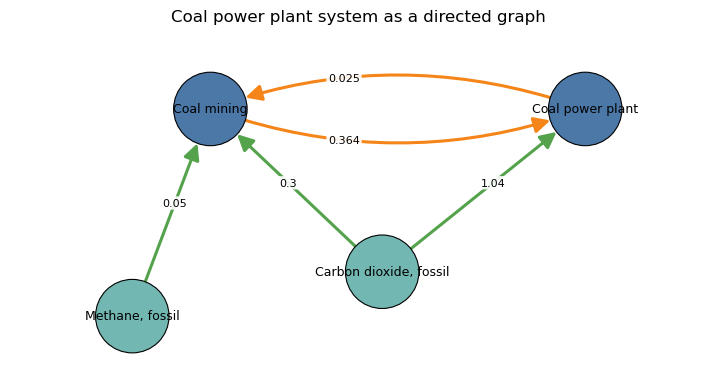

In [38]:
import matplotlib.pyplot as plt
import networkx as nx


def format_amount(value):
    return f'{value:.3f}'.rstrip('0').rstrip('.')


G = nx.DiGraph()

for act in bd.Database(tech_name):
    G.add_node(act.key, label=act['name'], kind='technosphere')

    for exc in act.technosphere():
        G.add_node(exc.input.key, label=exc.input['name'], kind='technosphere')
        G.add_edge(exc.input.key, act.key, amount=exc['amount'], kind='technosphere')

    for exc in act.biosphere():
        G.add_node(exc.input.key, label=exc.input['name'], kind='biosphere')
        G.add_edge(exc.input.key, act.key, amount=exc['amount'], kind='biosphere')

labels = {node: data['label'] for node, data in G.nodes(data=True)}
node_by_label = {data['label']: node for node, data in G.nodes(data=True)}

pos = {
    node_by_label['Coal mining']: (0.0, 1.0),
    node_by_label['Coal power plant']: (2.4, 1.0),
    node_by_label['Carbon dioxide, fossil']: (1.1, -0.1),
    node_by_label['Methane, fossil']: (-0.5, -0.4),
}

tech_edges = [(u, v) for u, v, data in G.edges(data=True) if data['kind'] == 'technosphere']
bio_edges = [(u, v) for u, v, data in G.edges(data=True) if data['kind'] == 'biosphere']
left_to_right = [(u, v) for u, v in tech_edges if pos[u][0] < pos[v][0]]
right_to_left = [(u, v) for u, v in tech_edges if pos[u][0] > pos[v][0]]

NODE_SIZE = 2800

node_colors = [
    '#4C78A8' if data['kind'] == 'technosphere' else '#72B7B2'
    for _, data in G.nodes(data=True)
]
label_box = {'boxstyle': 'round,pad=0.15', 'fc': 'white', 'ec': 'none', 'alpha': 0.9}

plt.figure(figsize=(9, 4.5))
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=NODE_SIZE,
    edgecolors='black',
    linewidths=0.8,
)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=left_to_right,
    edge_color='#F58518',
    width=2.2,
    node_size=NODE_SIZE,
    arrows=True,
    arrowsize=24,
    arrowstyle='-|>',
    min_source_margin=8,
    min_target_margin=18,
    connectionstyle='arc3,rad=0.18',
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=right_to_left,
    edge_color='#F58518',
    width=2.2,
    node_size=NODE_SIZE,
    arrows=True,
    arrowsize=24,
    arrowstyle='-|>',
    min_source_margin=8,
    min_target_margin=18,
    connectionstyle='arc3,rad=0.18',
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=bio_edges,
    edge_color='#54A24B',
    width=2.2,
    node_size=NODE_SIZE,
    arrows=True,
    arrowsize=24,
    arrowstyle='-|>',
    min_source_margin=8,
    min_target_margin=18,
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): format_amount(G.edges[u, v]['amount']) for u, v in left_to_right},
    font_size=8,
    label_pos=0.35,
    rotate=False,
    bbox=label_box,
    connectionstyle='arc3,rad=0.18',
)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): format_amount(G.edges[u, v]['amount']) for u, v in right_to_left},
    font_size=8,
    label_pos=0.65,
    rotate=False,
    bbox=label_box,
    connectionstyle='arc3,rad=0.18',
)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): format_amount(G.edges[u, v]['amount']) for u, v in bio_edges},
    font_size=8,
    label_pos=0.55,
    rotate=False,
    bbox=label_box,
)

plt.title('Coal power plant system as a directed graph')
plt.axis('off')
plt.margins(0.2)
plt.show()


## Common mistake

* Switching projects changes what databases and methods are visible. If something you created seems to have disappeared, first check the current project.
* If you modify an exchange or an activity but do not "commit" that change using the .save(), your changes will not be considered.

## Recap

After this notebook, you should be able to:

- explain what a project contains
- create or switch projects
- recognize that databases contain activities
- inspect production, technosphere, and biosphere exchanges
- explain that methods characterize biosphere flows, not technosphere flows
